Place for examples of capabilities. The following cell is the most reliable way I've found to accomplish the desired behavior, but it might be overkill.

In [1]:
using Pkg
Pkg.activate("..")
Pkg.instantiate()
Pkg.precompile()

  Activating project at `c:\Users\camde\.julia\dev\HybridDynamics.jl`
Precompiling packages...
    505.5 ms  ? HybridDynamics
Precompiling packages...
    449.1 ms  ? HybridDynamics


In [2]:
using Revise
import HybridDynamics as HD

ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


In [3]:
import Plots as plt
using LaTeXStrings

In [4]:
init = [1.,0.];
tspan = (0., 5.);

function M(q)
    [1.0;;]
end

function V(q)
    q[1]^2
end

# Table/guard
g(q) = q[1]

Lsys = HD.LagSys(M, V; guard = g)

probl = HD.prob(Lsys, init, tspan)
sl = HD.solve(probl)


┌ Warning: Step size has decreased below 1e-12
└ @ HybridDynamics c:\Users\camde\.julia\dev\HybridDynamics.jl\src\ODE_solvers.jl:206
┌ Warning: Step size has decreased below 1e-12
└ @ HybridDynamics c:\Users\camde\.julia\dev\HybridDynamics.jl\src\ODE_solvers.jl:206
┌ Warning: Step size has decreased below 1e-12
└ @ HybridDynamics c:\Users\camde\.julia\dev\HybridDynamics.jl\src\ODE_solvers.jl:206
┌ Warning: Step size has decreased below 1e-12
└ @ HybridDynamics c:\Users\camde\.julia\dev\HybridDynamics.jl\src\ODE_solvers.jl:206
┌ Warning: Step size has decreased below 1e-12
└ @ HybridDynamics c:\Users\camde\.julia\dev\HybridDynamics.jl\src\ODE_solvers.jl:206
┌ Warning: Step size has decreased below 1e-12
└ @ HybridDynamics c:\Users\camde\.julia\dev\HybridDynamics.jl\src\ODE_solvers.jl:206
┌ Warning: Step size has decreased below 1e-12
└ @ HybridDynamics c:\Users\camde\.julia\dev\HybridDynamics.jl\src\ODE_solvers.jl:206
┌ Warning: Step size has decreased below 1e-12
└ @ HybridDynamics c:\

HybridDynamics.LHSol{Vector{Float64}, Vector{Vector{Float64}}, Vector{Vector{Float64}}, HybridDynamics.prob{HybridDynamics.LagSys{typeof(M), typeof(V), typeof(g), HybridDynamics.var"#13#14"{typeof(g)}, HybridDynamics.var"#LagSys##2#LagSys##3", Float64}, Vector{Float64}, Tuple{Float64, Float64}}, Vector{Float64}, Vector{Float64}}([0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.060000000000000005, 0.11000000000000001, 0.2, 0.37  …  1.322473156135278, 1.6814979603068771, 2.3995475686500756, 2.8316158547445447, 2.8316158547445447, 3.8018579890455557, 3.8018579890455557, 4.233923366495306, 4.233923366495306, 5.0], [[1.0, 0.0], [0.9998000066661009, -0.01999800008948317], [0.999400093325746, -0.03998800124554792], [0.9988003799429394, -0.05996600706762061], [0.9980010264177027, -0.07992802435342126], [0.9970022325461088, -0.09987006389696437], [0.995804237972343, -0.1197881412856009], [0.9848549244155373, -0.21852128295700596], [0.9494354812834569, -0.39083073304780513], [0.8305548427371359, -0.6819816

In [5]:
print(sl.t)

[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.060000000000000005, 0.11000000000000001, 0.2, 0.37, 0.7, 1.0753375594104482, 1.0753375594104482, 2.0406751188208965, 0.963448351963679, 0.963448351963679, 1.226896703927358, 1.3784558484442677, 1.6815741374780873, 1.322473156135278, 1.6814979603068771, 2.3995475686500756, 2.8316158547445447, 2.8316158547445447, 3.8018579890455557, 3.8018579890455557, 4.233923366495306, 4.233923366495306, 5.0]

How tf am I going backwards in time...

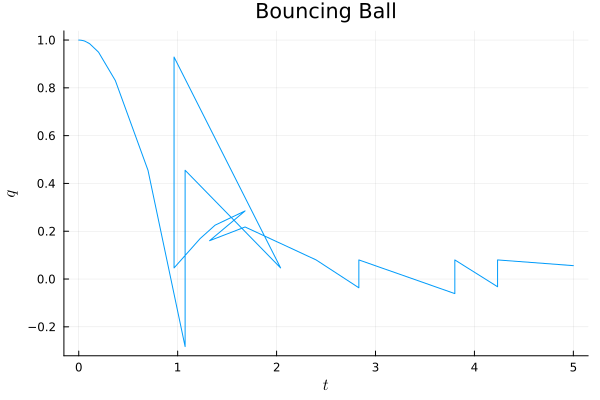

In [6]:
q_vals = getindex.(sl.x, 1)

pl2 = plt.plot(sl.t, q_vals,
    title = "Bouncing Ball",
    xlabel = L"t",
    ylabel = L"q",
    label = ""
)

display(pl2)

In [7]:
# Attempt a Filippov system
F(x) = [1, -1]
G(x) = [0, 1]
H(x) = x[2]-sin(x[1])
N(x) = [-cos(x[1]), 1]

Fsys = HD.FilippovSys(F, G, H, N)
probF = HD.prob(Fsys, [0.0, 1.0], (0.0, 5.0))
solF = HD.solve(probF, HD.RK4(); dt_initial=0.01)

MethodError: MethodError: no method matching (::HybridDynamics.var"#vf#44"{HybridDynamics.FilippovSys{typeof(F), typeof(G), typeof(H), typeof(N)}})(::Vector{Float64}, ::Float64)
The function `vf` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  (::HybridDynamics.var"#vf#44")(::Any)
   @ HybridDynamics c:\Users\camde\.julia\dev\HybridDynamics.jl\src\Systems\Filippov.jl:130
